In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# читаем данные
df = pd.read_csv('./База для анализа 26.11.2023.xlsx - Рабочий лист.csv')
df.head()

,iv id,Номер пациента,Номер клинического случая,Номер истории болезни,Номер диска в базе данных,Пол,Дата рождения,Возраст,"Рост, см","Вес, кг",Дата начала заболевания - СДС или КИНК,Сахарный диабет,Тип диабета,"Длительность анамнеза, лет",Степень тяжести диабета,Компенсация диабета,Удовлетворительная компенсация,Инсулинотерапия,Метформин,Джардинс,Гликлазид,Другие прапараты,Диализ,Нефропатия,Cтадия ХБП,Деформация стопы,Кардиальная патология,ИБС,Порок сердца,Степень порока сердца,Аортальный стеноз,Степень аортального стеноза,Митральная недостаточность,Степень митральной недостаточности,ФК стенокардии,ОИМ в анамнезе,Нарушения ритма сердца,Артериальная гипертензия (достигнутая степень),ХСН,"Фракция выброса ЭХО-КГ, %",ХВН,"ХВН (CEAP), Клинические критерии","ХВН (CEAP), Субъективные критерии",Поражение коронарных артерий,Язвенная болезнь,Кровотечения в анамнезе,ОНМК в анамнезе,Поражение МАГ,Поражение почечных артерий,Венозный тромбоз,Онкопатология в анамнезе,Ампутация другой нижней конечности,Курение,Сосудистые вмешательства в анамнезе,На ведущей НК,На МАГ,На почечных артериях,На артериях НК (кроме ведущей),Другие,Сторона поражения,Степень ХИНК (Ишемии Нижних Конечностей),Вид трофики перед РЭВ,Краткое описание характера поражения,Количество пораженных ангиосомов,Ангиосом 1 (ПББА),Ангиосом 2 (ЗББА),Ангиосом 3 (МБА),Wound,Ischemia,Foot Infection,Wagner,"TcpO2, мм рт. ст.","ЛПИ ЗББА, исходно","ЛПИ АТС, исходно",Дуплекс,КТ-ангиография,КТ-ангиография с перфузией,Ангиография,CO2-ангиография,Подвздошный сегмент,Бедренно-подколенный сегмент,Сегмент голени,Сегмент стопы,Число пораженных сегментов конечности,Малая ампутация до РЭВ,Малая ампутация после РЭВ,Вариант строения подколенной артерии (по D. Kim),Вариант анатомии артерии тыла стопы,"Гемоглобин, г/л","Лейкоциты, 10^9/л","Тромбоциты, 10^9/л","Общий белок, г/л","Альбумин, г/л","Глюкоза крови, ммоль/л","Гликированный гемоглобин, %","Креатинин, ммоль/л",СКФ MDRD,"С-реактивный белок, мг/л","Холестерин, ммоль/л","ЛПНП, ммоль/л","ЛПОНП, ммоль/л","Холестерин ЛПВП, ммоль/л","Триглицериды, ммоль/л",Дислипидемия,"АЧТВ, сек","ПТИ, 70-130","МНО, ед.","Фибриноген, г/л","NTpro BNP, пг/мл",Определение маркеров тромбофилии,D-димер,Фибриноген,Антитромбин III,Волчаночный антикоагулянт,Гомоцистеин,C-протеин,S-протеин,F2,F5,F13A1,FGB,ITGA2,ITGB3,SERPINE1,Маркеры АФС,АДФ-агрегация тромбоцитов при приеме Клопидогрела,АДФ-агрегация тромбоцитов при приеме Тикагрелора,Анти-Xa,Тромбодинамика,"V, скорость, мкм/мин","Tlag, задержка роста, мин","Vi, начальная скорость, мкм/мин",Дата вмешательства,Повторное вмешательство на конечности,Прием дженериков,Нерегулярный прием препаратов,Несоблюдение сроков контрольных осмотров,Отсутствие разгрузки стопы при лечении,Хроническая сердечная недостаточность,Декомпенсация СД,Прогрессирование атеросклероза,Неконтролируемая инфекция,Большой объем поражения,Срок после первого вмеш-ва,Тромболизис,Использование CO2-ангиографии,Антеградный доступ,Контралатеральный доступ,Ретроградный доступ,Комбинированное вмешательство (открытый+эндоваскулярный),Вмешательство на подвздошных артериях,Вмешательство на б-подколенном сегменте,Вмешательство на арт-х голени и стопы,Стентирование ПБА/ПкА,Стентирование артерий голени,Ретроградная реканализация,Вмешательство на шунтах,Использование лекарственных баллонов,Направленная катетерная атерэктомия (Turbohawk),Rotarex/Aspirex,Тип артериальной дуги стопы,"Ведущая артерия, формирующая артериальную дугу стопы",Тип реваскуляризации зоны на стопе,Название контрастного вещества (МНН),"Объем контрастного вещества, мл",ЗББА,ПББА,МБА,АТС,ЛПА,"ЛПИ ЗББА, после","ЛПИ АТС, после",Осложнение вмешательства,"Кровотечение малое (подкожное, компрессионный гемостаз)",Кровотечение большое (сосудистая операция),Тромбоз (в послеоперационном периоде),Тромбоз (в ходе вмешательства),"ОПН, КИН",ОИМ,Инсульт,Летальный исход,Комментарии вмешательства,Не проводилась,Вектор ОПА,Балл ОПА,Вектор НПА,Балл НПА,Вектор ВПА,Балл ВПА,Вектор ОБА,Балл ОБА,Вектор ГАБ,Балл ГАБ,Вектор ПБА,Балл

# 1. Обработка сырых данных

### 1.1. Первоначальная очистка данных

In [2]:
# удаляем столбцы если все строки NaN
df = df.dropna(axis=1, how='all')

# удаляем статичные признаки
print('Статичные признаки:')
for c in df.columns:
    if len(df[c].unique()) == 1:
        print(c)
        df = df.drop(columns=[c])

df.shape

Статичные признаки:
Метформин
Джардинс
Гликлазид
Другие прапараты
Кровотечения в анамнезе
CO2-ангиография
Маркеры АФС
Тромболизис
ОПН, КИН
ОИМ
Инсульт
Летальный исход
Не проводилась.1


(443, 250)

In [3]:
df.dtypes

iv id                                                                  int64
Номер пациента                                                         int64
Номер клинического случая                                              int64
Номер истории болезни                                                 object
Номер диска в базе данных                                             object
Пол                                                                   object
Дата рождения                                                         object
Возраст                                                              float64
Рост, см                                                             float64
Вес, кг                                                              float64
Дата начала заболевания - СДС или КИНК                                object
Сахарный диабет                                                       object
Тип диабета                                                          float64

### 1.2. Обработка данных по колонкам
Заметим, что колонки, в названия которых входят запятые, содержат в себе численные характерикстики. 


В этом случае заменим nan'ы на -1.


In [4]:
df['Лейкоциты, 10^9/л'].unique()

array([nan, '8,8', '6,1', '8', '10,4', '4,1', '9,4', '15,6', '14,8',
       '4,4', '10,6', '11,6', '6,3', '6,7', '8,6', '14', '21,4', '6,4',
       '7,4', '9,7', '12,5', '7,7', '7,3', '9,16', '7,8', '12', '17,1',
       '15', '6,9', '7,5', '7,9', '8,4', '5,2', '10,7', '6', '22', '13,4',
       '6,8', '14,3', '5,7', '15,9', '5,5', '13', '10', '7', '6,6', '6,5',
       '8,1', '9,9', '3,4', '9', '9,3', '13,8', '9,1', '7,6', '12,6',
       '12,3', '8,7', '8,3', '10,2', '8,9', '13,5', '5,6', '159', '11,3',
       '13,3', '10,3', '5', '11,4', '11,2', '11,7', '20', '4,98', '9,5',
       '6,2', '8,2', '16,3', '10,5', '8,5', '10,9', '9,8', '17,6', '14,1',
       '13,2', '11', '7,1', '9,6', '12,2', '13,6', '12,4', '25,1', '12,8',
       '5,3', '17', '3,5', '4,5', '7,2', '10,8', '5,4', '12,7', '21',
       '4,7', '12,1', '7,28', '13,57', '9,91', '7,89', '10,59', '9,08',
       '6,55', '11,8', '7,34'], dtype=object)

In [5]:
print("Численные характеристики:")

# преобразование в числовые
def to_numeric(x):
    try:
        return float(x.replace(',', '.'))
    except:
        return x
    
processed_cols = []

for c in df.columns:
    if ',' in c and c not in ['ХВН (CEAP), Клинические критерии', 'Ведущая артерия, формирующая артериальную дугу стопы']:
        print(c)
        df[c] = df[c].apply(to_numeric).astype('float')
        
        # заполняем пропуски
        df[c] = df[c].fillna(-1)
        processed_cols.append(c)

Численные характеристики:
Рост, см
Вес, кг
Длительность анамнеза, лет
Фракция выброса ЭХО-КГ, %
ХВН (CEAP), Субъективные критерии
TcpO2, мм рт. ст.
ЛПИ ЗББА, исходно
ЛПИ АТС, исходно
Гемоглобин, г/л
Лейкоциты, 10^9/л
Тромбоциты, 10^9/л
Общий белок, г/л
Альбумин, г/л
Глюкоза крови, ммоль/л
Гликированный гемоглобин, %
Креатинин, ммоль/л
С-реактивный белок, мг/л
Холестерин, ммоль/л
ЛПНП, ммоль/л
ЛПОНП, ммоль/л
Холестерин ЛПВП, ммоль/л
Триглицериды, ммоль/л
АЧТВ, сек
ПТИ, 70-130
МНО, ед.
Фибриноген, г/л
V, скорость, мкм/мин
Tlag, задержка роста, мин
Vi, начальная скорость, мкм/мин
Объем контрастного вещества, мл
ЛПИ ЗББА, после
ЛПИ АТС, после
Кровотечение малое (подкожное, компрессионный гемостаз)
Длительность/прогнозируемая длительность приема, месяцев
Длительность/прогнозируемая длительность приема, месяцев.1
PRU базовый, ед
PRU после приема препарата, ед
МНО, среднее значение
Доза, мг/сут
Длительность/прогнозируемая длительность приема, месяцев.3
Доза, мг/сут.1
Дозировка, мг/сут
Продолж

Анализ и обработка булевых колонок (в них можно ничего не менять)

In [6]:
bool_cols = df.dtypes[df.dtypes == 'bool'].index.tolist()

print("Пропусков в булевых колонках: ", df[bool_cols].isna().sum().sum())

processed_cols = list(set(processed_cols + bool_cols))
print('Всего колонок обработано: ', len(processed_cols))

Пропусков в булевых колонках:  0
Всего колонок обработано:  98


"Баллы" и "Векторы" - это числовые колонки

In [7]:
for c in df.columns:
    if 'Балл' in c or 'Вектор' in c:
        df[c] = df[c].fillna(-1)
        processed_cols.append(c)
        df[c] = df[c].astype('float')
        
len(processed_cols)

159

In [8]:
df['Сахарный диабет'].value_counts()

Сахарный диабет
True     210
False     62
Name: count, dtype: int64

### Обрабатывать данные можно сколько угодно, давайте лучше поработаем с теми признаками, которые мы уже имеем

In [9]:
processed_df = df[processed_cols]
processed_df.head() 

,Прием дженериков,ЗББА,ПББА,"ЛПИ ЗББА, после",Сегмент стопы,"Вес, кг","Tlag, задержка роста, мин",Малая ампутация до РЭВ,"Гликированный гемоглобин, %",МБА,"Фибриноген, г/л","Длительность/прогнозируемая длительность приема, месяцев",Антеградный доступ,Тромбоз (в ходе вмешательства),"PRU базовый, ед","ЛПОНП, ммоль/л",ХВН,Деформация стопы,"АЧТВ, сек",Подвздошный сегмент,"ЛПИ АТС, исходно",Не проводилась,"Препараты простагландина Е2 (вазапростан, алпростан, алпростадил)","Тромбоциты, 10^9/л","ПТИ, 70-130","Холестерин ЛПВП, ммоль/л",Хроническая сердечная недостаточность,"Триглицериды, ммоль/л","Дозировка, мг/сут",Ангиография,"Продолжительность, мес.","Vi, начальная скорость, мкм/мин","PRU после приема препарата, ед",Инсулинотерапия,Дислипидемия,"Гемоглобин, г/л","Холестерин, ммоль/л",Контралатеральный доступ,Кровотечение большое (сосудистая операция),Бедренно-подколенный сегмент,"Фракция выброса ЭХО-КГ, %",Вмешательство на арт-х голени и стопы,Rotarex/Aspirex,"ЛПИ АТС, после","Длительность/прогнозируемая длительность приема, месяцев.3","ЛПНП, ммоль/л",КТ-ангиография с перфузией,АТС,"ХВН (CEAP), Субъективные критерии",Использование лекарственных баллонов,Вмешательство на подвздошных артериях,Удовлетворительная компенсация,"Глюкоза крови, ммоль/л",Нерегулярный прием препаратов,"Длительность/прогнозируемая длительность приема, месяцев.1","МНО, ед.",Прогрессирование атеросклероза,Использование CO2-ангиографии,Вмешательство на шунтах,"Рост, см",Тромбоз (в послеоперационном периоде),Комбинированное вмешательство (открытый+эндоваскулярный),Несоблюдение сроков контрольных осмотров,Сегмент голени,"Длительность анамнеза, лет",Вмешательство на б-подколенном сегменте,Отсутствие разгрузки стопы при лечении,КТ-ангиография,Большой объем поражения,Декомпенсация СД,Неконтролируемая инфекция,"Альбумин, г/л",На МАГ,"Кровотечение малое (подкожное, компрессионный гемостаз)",На почечных артериях,Повторное вмешательство на конечности,"Общий белок, г/л",Ретроградная реканализация,"Доза, мг/сут","ЛПИ ЗББА, исходно",Ангиосом 3 (МБА),"Креатинин, ммоль/л","МНО, среднее значение","Объем контрастного вещества, мл",На артериях НК (кроме ведущей),Дуплекс,Ретроградный доступ,Направленная катетерная атерэктомия (Turbohawk),ЛПА,"Лейкоциты, 10^9/л","Доза, мг/сут.1","TcpO2, мм рт. ст.",Малая ампутация после РЭВ,"С-реактивный белок, мг/л","V, скорость, мкм/мин",Ангиосом 2 (ЗББА),Ангиосом 1 (ПББА),Нефропатия,Вектор ОПА,Балл ОПА,Вектор НПА,Балл НПА,Вектор ВПА,Балл ВПА,Вектор ОБА,Балл ОБА,Вектор ГАБ,Балл ГАБ,Вектор ПБА,Балл ПБА,Вектор ПоА,Балл ПоА,Вектор ТПС,Балл ТПС,Вектор ПББА,Балл ПББА,Вектор ЗББА,Балл ЗББА,Вектор МБА,Балл МБА,Вектор АТС,Балл АТС,Вектор ЛПА,Балл ЛПА,Вектор МПА,Балл МПА,Вектор ПАД,Балл ПАД,Вектор ОПА.1,Балл ОПА.1,Вектор НПА.1,Балл НПА.1,Вектор ВПА.1,Балл ВПА.1,Вектор ОБА.1,Балл ОБА.1,Вектор ГАБ.1,Балл ГАБ.1,Вектор ПБА.1,Балл ПБА.1,Вектор ПоА.1,Балл ПоА.1,Вектор ТПС.1,Балл ТПС.1,Вектор ПББА.1,Балл ПББА.1,Вектор ЗББА.1,Балл ЗББА.1,Вектор МБА.1,Балл МБА.1,Вектор АТС.1,Балл АТС.1,Вектор ЛПА.1,Балл ЛПА.1,Вектор МПА.1,Балл МПА.1,Вектор ПАД.1,Балл ПАД.1,Балл по Bolinger после операции
0,False,False,False,-1.0,False,-1.0,-1.0,True,-1.0,False,-1.0,-1.0,False,False,-1.0,-1.0,False,False,-1.0,False,-1.0,False,-1.0,-1.0,-1.0,-1.0,False,2.24,-1.0,False,-1.0,-1.0,-1.0,True,True,-1.0,4.95,False,False,False,-1.0,False,False,-1.0,-1.0,-1.0,False,False,-1.0,False,False,False,4.60,False,-1.0,-1.0,False,False,False,-1.0,False,False,False,False,13.0,False,False,False,False,False,False,-1.0,False,0.0,False,False,-1.0,False,-1.0,-1.0,False,91.0,-1.0,-1.0,False,False,False,False,False,-1.0,-1.0,-1.0,False,-1.0,-1.0,False,False,True,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,601.0,7.0,5000.0,15.0,5000.0,15.0,500.0,5.0,500.0,5.0,640.0,10.0,-1.0,-1.0,3000.0,13.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,5000.0,15.0,5000.0,15.0,2.0,2.0,500.0,5.0,640.0,10.0,-1.0,-1.0,3000.0,13.0,-1.0
1,False,False,False,-1.0,False,-1.0,

# Гипотеза и анализ

### 2.1. Мы предполагаем, что между диагнозом Нефропатии и признаками Балл + Вектор можно найти зависимость

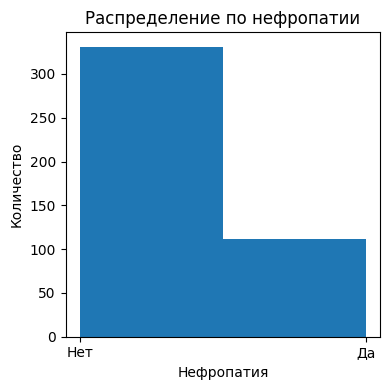

In [10]:
plt.figure(figsize=(4, 4))
plt.title('Распределение по нефропатии')
plt.xlabel('Нефропатия')
plt.ylabel('Количество')
plt.xticks([0, 1], ['Нет', 'Да'])
plt.hist(processed_df['Нефропатия'].astype(int), bins=2)
plt.tight_layout()
plt.show()

In [11]:
ball_vector_df = processed_df[processed_df.columns[processed_df.columns.str.contains('Балл') | processed_df.columns.str.contains('Вектор')]]
ball_vector_df.sum().sum()

10621723.0

In [12]:
ball_vector_df.head()

,Вектор ОПА,Балл ОПА,Вектор НПА,Балл НПА,Вектор ВПА,Балл ВПА,Вектор ОБА,Балл ОБА,Вектор ГАБ,Балл ГАБ,Вектор ПБА,Балл ПБА,Вектор ПоА,Балл ПоА,Вектор ТПС,Балл ТПС,Вектор ПББА,Балл ПББА,Вектор ЗББА,Балл ЗББА,Вектор МБА,Балл МБА,Вектор АТС,Балл АТС,Вектор ЛПА,Балл ЛПА,Вектор МПА,Балл МПА,Вектор ПАД,Балл ПАД,Вектор ОПА.1,Балл ОПА.1,Вектор НПА.1,Балл НПА.1,Вектор ВПА.1,Балл ВПА.1,Вектор ОБА.1,Балл ОБА.1,Вектор ГАБ.1,Балл ГАБ.1,Вектор ПБА.1,Балл ПБА.1,Вектор ПоА.1,Балл ПоА.1,Вектор ТПС.1,Балл ТПС.1,Вектор ПББА.1,Балл ПББА.1,Вектор ЗББА.1,Балл ЗББА.1,Вектор МБА.1,Балл МБА.1,Вектор АТС.1,Балл АТС.1,Вектор ЛПА.1,Балл ЛПА.1,Вектор МПА.1,Балл МПА.1,Вектор ПАД.1,Балл ПАД.1,Балл по Bolinger после операции
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,601.0,7.0,5000.0,15.0,5000.0,15.0,500.0,5.0,500.0,5.0,640.0,10.0,-1.0,-1.0,3000.0,13.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,5000.0,15.0,5000.0,15.0,2.0,2.0,500.0,5.0,640.0,10.0,-1.0,-1.0,3000.0,13.0,-1.0
1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,5000.0,15.0,3000.0,13.0,0.0,0.0,5000.0,15.0,3000.0,13.0,-1.0,-1.0,30.0,3.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,5000.0,15.0,0.0,0.0,0.0,0.0,5000.0,15.0,0.0,0.0,-1.0,-1.0,30.0,3.0,-1.0
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,5000.0,15.0,3000.0,13.0,2.0,2.0,5000.0,15.0,30.0,3.0,-1.0,-1.0,3.0,3.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,5000.0,15.0,0.0,0.0,2.0,2.0,5000.0,15.0,0.0,0.0,-1.0,-1.0,3.0,3.0,-1.0
3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,3000.0,13.0,540.0,9.0,640.0,10.0,20.0,2.0,403.0,7.0,-1.0,-1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,2.0,2.0,540.0,9.0,3.0,3.0,2.0,2.0,403.0,7.0,-1.0,-1.0,0.0,0.0,-1.0
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,30.0,3.0,3000.0,13.0,5000.0,15.0,3000.0,13.0,2.0,2.0,3000.0,13.0,-1.0,-1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,21.0,3.0,3000.0,13.0,5000.0,15.0,21.0,3.0,2.0,2.0,3000.0,13.0,-1.0,-1.0,0.0,0.0,-1.0


Посмотрим на зависимость какого-нибудь балла и вектора и нефропатии

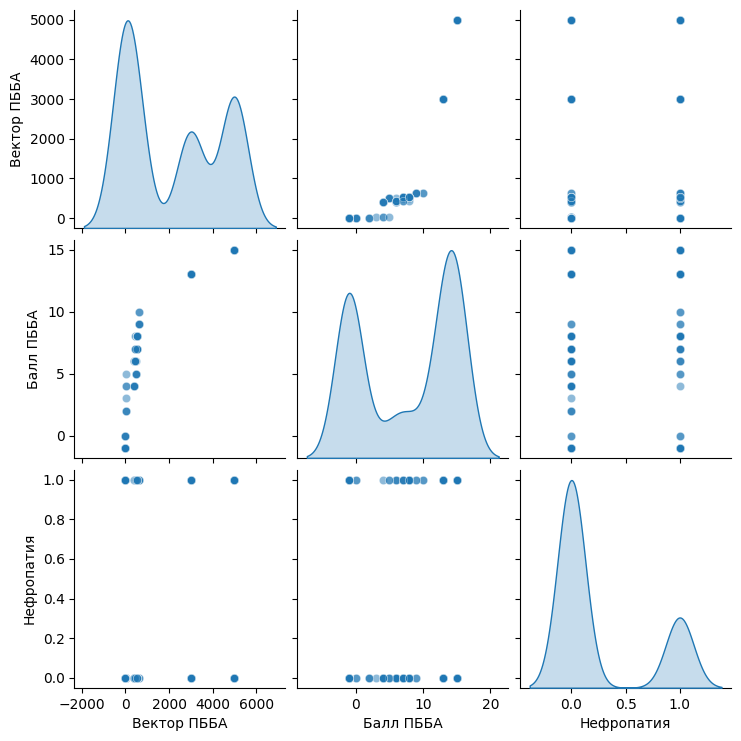

In [13]:
combined_df = processed_df.copy()
combined_df['Нефропатия'] = combined_df['Нефропатия'].astype(int)

g = sns.pairplot(combined_df[['Вектор ПББА', 'Балл ПББА', 'Нефропатия']], diag_kind='kde', plot_kws={'alpha': 0.5})

### Наглядной картины не наблюдается

# Проверка гипотезы

### Для начала уменьшим размерность наших данных с помощью метода главных компонент

Попробуем на глаз разбить на 2 класса

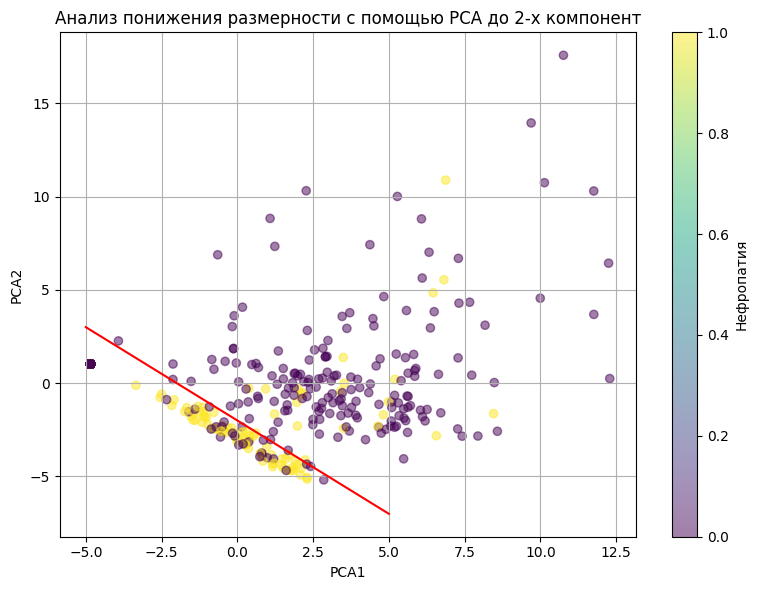

In [14]:
# стандартизация данных
scaler = StandardScaler()
ball_vector_df_scaled = scaler.fit_transform(ball_vector_df)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(ball_vector_df_scaled)
pca_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
pca_df['Нефропатия'] = combined_df['Нефропатия'].values
plt.figure(figsize=(8, 6))

plt.grid(True)
plt.title('Анализ понижения размерности с помощью PCA до 2-х компонент')
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], c=pca_df['Нефропатия'], cmap='viridis', alpha=0.5)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar(label='Нефропатия')
plt.tight_layout()
plt.plot([-5, 5], [3, -7], color='red', linestyle='-')

plt.show()

Тут уже на глаз видно, что можно разделить больных нефропатией и не больных нефропатией прямой линией pca_df['PCA1'] <= -1.25*pca_df['PCA2'] - 3.25


Посчитаем точность нашей грубой модели

In [15]:
pca_df['predicted'] = (pca_df['PCA1'] <= -1.25*pca_df['PCA2'] - 3.25).astype(int)

# classification report
print('Classification report:')
print(classification_report(pca_df['Нефропатия'], pca_df['predicted'], target_names=['Нет', 'Да']))
print('Balanced accuracy score:', balanced_accuracy_score(pca_df['Нефропатия'], pca_df['predicted']))

Classification report:
              precision    recall  f1-score   support

         Нет       0.83      0.55      0.66       331
          Да       0.34      0.68      0.45       112

    accuracy                           0.58       443
   macro avg       0.59      0.61      0.56       443
weighted avg       0.71      0.58      0.61       443

Balanced accuracy score: 0.6126996115666811


### Обучим логистическую регрессию и сравним результаты

              precision    recall  f1-score   support

           0       0.85      0.95      0.90        66
           1       0.80      0.52      0.63        23

    accuracy                           0.84        89
   macro avg       0.83      0.74      0.77        89
weighted avg       0.84      0.84      0.83        89



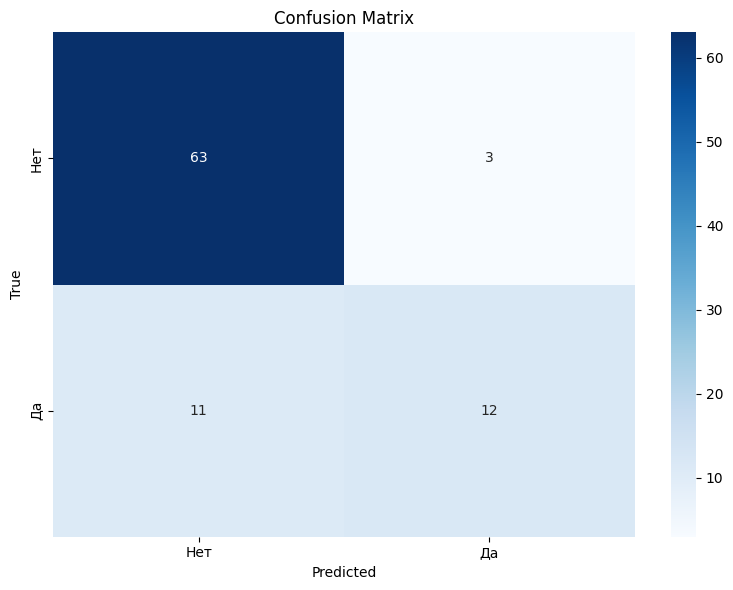

Balanced accuracy score: 0.7381422924901186


In [ ]:
# PCA
pca = PCA(n_components=30)
pca_result = pca.fit_transform(ball_vector_df_scaled)
pca_df = pd.DataFrame(data=pca_result, columns=[f'PCA{i+1}' for i in range(30)])
pca_df['Нефропатия'] = combined_df['Нефропатия'].values

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    pca_df.drop(columns=['Нефропатия']),
    pca_df['Нефропатия'],
    test_size=0.2,
    random_state=42,
    stratify=pca_df['Нефропатия']
)

# Обучение логистической регрессии
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = log_reg.predict(X_test)

# Оценка модели
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Нет', 'Да'], yticklabels=['Нет', 'Да'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print('Balanced accuracy score:', balanced_accuracy_score(y_test, y_pred))